# Zero-Shot Classification of Crisis-Related News for Forecasting Flight Cancellations

**Team Members:** Rishiv Bawa, Gaurav Sharma, Veekshith Sumanth  
**Research Question:** Can Zero-Shot Classification applied to crisis-related news headlines predict international flight cancellations?  
**Hypothesis:** Zero-Shot Classification techniques can identify news articles containing crisis-related indicators with ≥70% precision when validated against actual recorded flight cancellation surges in public aviation datasets.

## Pipeline Overview
- **Stage 1:** Raw Data (GDELT crisis events + Flight cancellation records)
- **Stage 2:** Filtered & Classified (Zero-shot disruption labels, sentiment, temporal aggregation, community detection)
- **Stage 3:** Actionable Intelligence (Correlation analysis, predictive patterns, lead-time forecasting)

---
## STAGE 1: RAW DATA COLLECTION
### 3.1 Data Collection (Methodology)

In [9]:
# =========================
# Install Required Libraries
# =========================
!pip install -q pandas numpy matplotlib seaborn
!pip install -q transformers torch sentence-transformers
!pip install -q scikit-learn networkx python-louvain
!pip install -q huggingface-hub datasets


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Libraries imported successfully")
print(f"Random seed set to: {RANDOM_SEED}")

Libraries imported successfully
Random seed set to: 42


### Data Source 1: GDELT Crisis Events

**Methodology (3.1):**
- **Source:** GDELT Events 2.0 database (https://www.gdeltproject.org/)
- **Time Period:** January 2024 - December 2024
- **Raw Records:** ~30 million global events
- **Selection Criteria:** Events filtered by CAMEO crisis codes (14=Protest, 17=Coerce, 18=Assault, 19=Fight, 20=Mass Violence) AND aviation-related keywords
- **Final Crisis Events:** 11,113 records
- **Justification:** GDELT provides structured, timestamped event data from global news sources, enabling temporal correlation analysis without manual news scraping

In [11]:
# Load preprocessed GDELT crisis-aviation events
# Using GDELT_2024_Dataset.csv (filtered for 2024 only)

try:
    df_crisis = pd.read_csv("gdelt_crisis_aviation_clean.csv")
    print("Loaded existing cleaned dataset")
    
    # Ensure data is filtered to 2024 only
    df_crisis['Day'] = df_crisis['Day'].astype(str)
    df_crisis = df_crisis[df_crisis['Day'].str.startswith('2024')].copy()
    print(f"Filtered to 2024 events only: {len(df_crisis)} records")
    
except FileNotFoundError:
    print("Creating crisis dataset from raw GDELT data...")
    # If raw file exists, process it
    try:
        df_raw = pd.read_csv("GDELT_2024_Dataset.csv", header=None, low_memory=False)
        
        # GDELT column assignment (first 58 columns)
        base_cols = [
            "GlobalEventID","Day","MonthYear","Year","FractionDate",
            "Actor1Code","Actor1Name","Actor1CountryCode","Actor1KnownGroupCode","Actor1EthnicCode",
            "Actor1Religion1Code","Actor1Religion2Code","Actor1Type1Code","Actor1Type2Code","Actor1Type3Code",
            "Actor2Code","Actor2Name","Actor2CountryCode","Actor2KnownGroupCode","Actor2EthnicCode",
            "Actor2Religion1Code","Actor2Religion2Code","Actor2Type1Code","Actor2Type2Code","Actor2Type3Code",
            "IsRootEvent","EventCode","EventBaseCode","EventRootCode",
            "QuadClass","GoldsteinScale","NumMentions","NumSources","NumArticles","AvgTone",
            "Actor1Geo_Type","Actor1Geo_Fullname","Actor1Geo_CountryCode","Actor1Geo_ADM1Code","Actor1Geo_ADM2Code",
            "Actor1Geo_Lat","Actor1Geo_Long","Actor1Geo_FeatureID",
            "Actor2Geo_Type","Actor2Geo_Fullname","Actor2Geo_CountryCode","Actor2Geo_ADM1Code","Actor2Geo_ADM2Code",
            "Actor2Geo_Lat","Actor2Geo_Long","Actor2Geo_FeatureID",
            "ActionGeo_Type","ActionGeo_Fullname","ActionGeo_CountryCode","ActionGeo_ADM1Code",
            "ActionGeo_ADM2Code","ActionGeo_Lat","ActionGeo_Long","ActionGeo_FeatureID",
            "DATEADDED","SOURCEURL"
        ]
        df_raw.columns = base_cols[:df_raw.shape[1]]
        
        # Filter to 2024 events only (FIRST STEP)
        print("Filtering for 2024 events...")
        df_raw['Day'] = df_raw['Day'].astype(str)
        df_raw = df_raw[df_raw['Day'].str.startswith('2024')].copy()
        print(f"  Events in 2024: {len(df_raw):,}")
        
        # Crisis event filtering (CAMEO codes)
        crisis_codes = ['14', '17', '18', '19', '20']
        df_crisis = df_raw[df_raw['EventRootCode'].astype(str).isin(crisis_codes)].copy()
        print(f"  Crisis events (codes {crisis_codes}): {len(df_crisis):,}")
        
        # Aviation keyword filtering
        aviation_keywords = ['airport', 'airline', 'flight', 'aviation', 'runway', 'terminal',
                           'plane', 'jet', 'air traffic', 'atc', 'boeing', 'airbus']
        
        def has_aviation_keyword(row):
            text = f"{row.get('Actor1Name', '')} {row.get('Actor2Name', '')} {row.get('ActionGeo_Fullname', '')}".lower()
            return any(kw in text for kw in aviation_keywords)
        
        df_crisis = df_crisis[df_crisis.apply(has_aviation_keyword, axis=1)].copy()
        print(f"  Aviation-related crisis events: {len(df_crisis):,}")
        
        # Save cleaned version
        df_crisis.to_csv("gdelt_crisis_aviation_clean.csv", index=False)
        print(f"\n✓ Created and saved cleaned crisis dataset: {len(df_crisis)} events (2024 only)")
    except FileNotFoundError:
        print("ERROR: No GDELT data file found. Please provide GDELT_2024_Dataset.csv or gdelt_crisis_aviation_clean.csv")
        df_crisis = None

if df_crisis is not None:
    print(f"\nCrisis Events Dataset:")
    print(f"Total records: {len(df_crisis):,}")
    print(f"Date range: {df_crisis['Day'].min()} to {df_crisis['Day'].max()}")
    print(f"Columns: {df_crisis.columns.tolist()[:10]}...")
    print(f"\nEvent Root Code Distribution:")
    print(df_crisis['EventRootCode'].value_counts())

Loaded existing cleaned dataset
Filtered to 2024 events only: 10122 records

Crisis Events Dataset:
Total records: 10,122
Date range: 20240101 to 20241002
Columns: ['GlobalEventID', 'Day', 'MonthYear', 'Year', 'FractionDate', 'Actor1Code', 'Actor1Name', 'Actor1CountryCode', 'Actor1KnownGroupCode', 'Actor1EthnicCode']...

Event Root Code Distribution:
EventRootCode
19    5718
17    2736
18    1028
14     560
20      80
Name: count, dtype: int64


### Data Source 2: Flight Cancellation Records

**Methodology (3.1 continued):**
- **Source:** Provided `flight_data_2024.csv` file.
- **Time Period:** January 2024 - February 2024
- **Records:** Flight-level records for US domestic flights
- **Variables:** Date, Origin Airport, Cancellation Status, Delays, and more (18 variables total)
- **Data Characteristics:** Real flight operations data with 1M+ flight records
- **Justification:** Using provided flight data enables direct analysis of actual cancellation patterns without requiring API access or manual data collection

In [12]:
# Load flight cancellation data from provided file
# File: flight_data_2024.csv

print("Loading flight cancellation data from flight_data_2024.csv...")
try:
    # Load the flight data from provided CSV file
    df_flights_raw = pd.read_csv("flight_data_2024.csv")
    
    print(f"Flight Data Loaded Successfully:")
    print(f"Total records: {len(df_flights_raw):,}")
    print(f"\nColumns available: {df_flights_raw.columns.tolist()}")
    
    # Convert fl_date to datetime
    df_flights_raw['date'] = pd.to_datetime(df_flights_raw['fl_date'])
    
    # Check date range
    print(f"\nDate range: {df_flights_raw['date'].min()} to {df_flights_raw['date'].max()}")
    
    # Aggregate to daily level: sum cancellations and count total flights
    print("\nAggregating to daily cancellation statistics...")
    df_flights_daily = df_flights_raw.groupby('date').agg({
        'cancelled': ['sum', 'count']
    }).reset_index()
    
    # Flatten column names
    df_flights_daily.columns = ['date', 'cancelled_flights', 'total_flights']
    
    # Calculate cancellation rate
    df_flights_daily['cancellation_rate'] = (
        df_flights_daily['cancelled_flights'] / df_flights_daily['total_flights']
    )
    
    # Identify cancellation spikes (>3 standard deviations above mean)
    mean_cancel_rate = df_flights_daily['cancellation_rate'].mean()
    std_cancel_rate = df_flights_daily['cancellation_rate'].std()
    df_flights_daily['is_spike'] = (
        df_flights_daily['cancellation_rate'] > (mean_cancel_rate + 3 * std_cancel_rate)
    )
    
    print(f"\n✓ Daily aggregation complete:")
    print(f"  Total days: {len(df_flights_daily)}")
    print(f"  Mean cancellation rate: {mean_cancel_rate:.4f}")
    print(f"  Std dev: {std_cancel_rate:.4f}")
    print(f"  Days with cancellation spikes: {df_flights_daily['is_spike'].sum()}")
    
    print(f"\nSample daily statistics:")
    print(df_flights_daily.head(10))
    
    print(f"\nCancellation rate distribution:")
    print(df_flights_daily['cancellation_rate'].describe())
    
    # Save daily aggregated data
    df_flights_daily.to_csv("flight_cancellations_daily_2024.csv", index=False)
    print(f"\n✓ Saved daily aggregation to: flight_cancellations_daily_2024.csv")
    
except FileNotFoundError:
    print("ERROR: flight_data_2024.csv not found in current directory")
    print("Please ensure the flight_data_2024.csv file is in the working directory")
    df_flights_raw = None
    df_flights_daily = None
except Exception as e:
    print(f"ERROR loading flight data: {e}")
    df_flights_raw = None
    df_flights_daily = None

Loading flight cancellation data from flight_data_2024.csv...
Flight Data Loaded Successfully:
Total records: 1,048,575

Columns available: ['year', 'month', 'day_of_month', 'day_of_week', 'fl_date', 'origin', 'origin_city_name', 'origin_state_nm', 'dep_time', 'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in', 'cancelled', 'air_time', 'distance', 'weather_delay', 'late_aircraft_delay']

Date range: 2024-01-01 00:00:00 to 2024-02-29 00:00:00

Aggregating to daily cancellation statistics...

✓ Daily aggregation complete:
  Total days: 60
  Mean cancellation rate: 0.0221
  Std dev: 0.0327
  Days with cancellation spikes: 2

Sample daily statistics:
        date  cancelled_flights  total_flights  cancellation_rate  is_spike
0 2024-01-01                 18          17265           0.001043     False
1 2024-01-02                 25          18977           0.001317     False
2 2024-01-03                 19          18520           0.001026     False
3 2024-01-04                 65          18

---
## STAGE 1 COMPLETE

**Summary:**
- ✓ GDELT crisis events loaded from `GDELT_2024_Dataset.csv` and filtered for aviation-related incidents (2024 only)
- ✓ Flight cancellation data loaded from provided `flight_data_2024.csv` file
- ✓ Both datasets preprocessed and aggregated to daily level
- ✓ Temporal alignment ready (both datasets cover 2024)

**Output Files:**
- `gdelt_crisis_aviation_clean.csv` - Filtered crisis events (10,122 records, 2024 only)
- `flight_cancellations_daily_2024.csv` - Daily aggregated cancellation statistics (60 days)

**Data Coverage:**
- Crisis events: January 2024 - October 2024 (10,122 aviation-related crisis events)
- Flight data: January - February 2024 (1M+ flight records)
- Overlapping period for analysis: January - February 2024

**Event Distribution (Crisis Events):**
- Fight (19): 5,718 events
- Coerce (17): 2,736 events  
- Assault (18): 1,028 events
- Protest (14): 560 events
- Mass Violence (20): 80 events

Both datasets are now ready for Stage 2 preprocessing and classification.

---
## STAGE 2: DATA PREPROCESSING & CLASSIFICATION
### 3.2 Data Preprocessing (Methodology)

### Preprocessing Steps (Stage 1 → Stage 2 Transition)

**Methodology (3.2):**

**Crisis Events Preprocessing:**
1. **Timestamp Normalization:** Convert GDELT Day format (YYYYMMDD) to datetime objects
2. **Text Construction:** Create `event_text` from structured fields (Actor1, Actor2, Location, EventCode)
3. **Deduplication:** Remove events with identical (Day, EventRootCode, Actors, Location)
4. **Text Validity:** Filter events with insufficient textual content (<10 characters)
5. **Temporal Filtering:** Ensure all events fall within 2024

**Flight Data Preprocessing:**
1. **Date Alignment:** Ensure datetime format matches crisis events
2. **Aggregation:** Already completed in Stage 1 (daily aggregation)
3. **Outlier Detection:** Flag days with >3 standard deviations above mean (already done)

**Noise Reduction:**
- Crisis events: 30M → 10,122 (99.97% noise removed via crisis+aviation+2024 filtering)
- Flight records: All records valid (already aggregated to daily level)

In [13]:
# =========================
# Preprocess Crisis Events
# =========================

if df_crisis is not None:
    print(f"Starting preprocessing with {len(df_crisis):,} crisis events")
    
    # Convert Day to datetime
    print(f"\nStep 1: Timestamp Normalization")
    df_crisis['Day'] = df_crisis['Day'].astype(str)
    df_crisis['date'] = pd.to_datetime(df_crisis['Day'], format='%Y%m%d', errors='coerce')
    
    # Filter to valid 2024 dates (already done, but ensure no invalid dates)
    before_date_filter = len(df_crisis)
    df_crisis = df_crisis[df_crisis['date'].notna()].copy()
    print(f"  ✓ Converted Day format (YYYYMMDD) to datetime objects")
    print(f"  ✓ Valid dates: {len(df_crisis):,} events")
    
    # Create event_text if not exists
    if 'event_text' not in df_crisis.columns:
        print(f"\nStep 2: Text Construction")
        def build_event_text(row):
            actor1 = str(row.get('Actor1Name', '')).strip()
            actor2 = str(row.get('Actor2Name', '')).strip()
            location = str(row.get('ActionGeo_Fullname', '')).strip()
            code = str(row.get('EventRootCode', '')).strip()
            
            # More informative text construction
            text = f"Crisis event: {actor1} and {actor2} involved in incident at {location}. Event type code {code}."
            return text
        
        df_crisis['event_text'] = df_crisis.apply(build_event_text, axis=1)
        print(f"  ✓ Created event_text from structured fields (Actor1, Actor2, Location, EventCode)")
    
    # Filter by text length (minimum 10 characters)
    print(f"\nStep 3: Text Validity Filter")
    before_text_filter = len(df_crisis)
    df_crisis = df_crisis[df_crisis['event_text'].str.len() >= 10].copy()
    removed_text = before_text_filter - len(df_crisis)
    print(f"  ✓ Removed {removed_text} events with insufficient text (<10 chars)")
    
    # Remove duplicates
    print(f"\nStep 4: Deduplication")
    before_dedup = len(df_crisis)
    df_crisis = df_crisis.drop_duplicates(
        subset=['Day', 'EventRootCode', 'Actor1Name', 'Actor2Name', 'ActionGeo_Fullname']
    ).copy()
    removed_dupes = before_dedup - len(df_crisis)
    print(f"  ✓ Removed {removed_dupes} duplicate events")
    
    print(f"\n{'='*80}")
    print("PREPROCESSING COMPLETE (Stage 1 → Stage 2 Transition)")
    print(f"{'='*80}")
    print(f"Final preprocessed records: {len(df_crisis):,}")
    print(f"Date range: {df_crisis['date'].min().date()} to {df_crisis['date'].max().date()}")
    
    print(f"\nEvent Root Code Distribution:")
    print(df_crisis['EventRootCode'].value_counts())
    
    print(f"\nSample event texts:")
    for idx, row in df_crisis.head(3).iterrows():
        print(f"\n  • Date: {row['date'].date()}")
        print(f"    Code: {row['EventRootCode']}")
        print(f"    Text: {row['event_text'][:100]}...")
    
    # Save preprocessed data
    df_crisis.to_csv("crisis_events_preprocessed.csv", index=False)
    print(f"\n✓ Saved preprocessed data to: crisis_events_preprocessed.csv")
    print(f"\nData is now ready for Stage 2 processing:")
    print(f"  - Zero-Shot Classification")
    print(f"  - Clustering and Community Detection")
    print(f"  - Temporal Alignment with flight data")
else:
    print("Skipping crisis preprocessing - no data loaded")

Starting preprocessing with 10,122 crisis events

Step 1: Timestamp Normalization
  ✓ Converted Day format (YYYYMMDD) to datetime objects
  ✓ Valid dates: 10,122 events

Step 2: Text Construction
  ✓ Created event_text from structured fields (Actor1, Actor2, Location, EventCode)

Step 3: Text Validity Filter
  ✓ Removed 0 events with insufficient text (<10 chars)

Step 4: Deduplication
  ✓ Removed 1581 duplicate events

PREPROCESSING COMPLETE (Stage 1 → Stage 2 Transition)
Final preprocessed records: 8,541
Date range: 2024-01-01 to 2024-10-02

Event Root Code Distribution:
EventRootCode
19    4756
17    2357
18     869
14     494
20      65
Name: count, dtype: int64

Sample event texts:

  • Date: 2024-01-01
    Code: 17
    Text: Crisis event: AIRLINE and KUWAIT involved in incident at EZ81. Event type code 17....

  • Date: 2024-01-01
    Code: 17
    Text: Crisis event: AIRLINE and QATAR involved in incident at EZ81. Event type code 17....

  • Date: 2024-01-01
    Code: 17
    Text

### 3.3 Zero-Shot Classification (Methodology)

**Model Configuration:**
- **Model:** `MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli` (184M parameters)
- **Task:** Zero-shot text classification via Natural Language Inference (NLI)
- **Architecture:** DeBERTa-v3-base fine-tuned on MNLI, FEVER, and ANLI datasets
- **Implementation:** Hugging Face Transformers pipeline with zero-shot-classification support
- **Quantization:** None (full precision fp32)
- **Random Seed:** 42

**DeBERTa-v3 Zero-Shot Classification:**
Using DeBERTa-v3 with NLI-based zero-shot classification:
- **NLI Framework:** Treats classification as entailment problem (hypothesis vs premise)
- **Robust Training:** Fine-tuned on MNLI, FEVER, and ANLI for strong generalization
- **Disentangled Attention:** DeBERTa's improved attention mechanism for better context understanding
- **Calibrated Scores:** Returns well-calibrated probability distributions across categories
- **No Training Required:** True zero-shot - works on any category labels without retraining
- **Wide Accessibility:** Microsoft's DeBERTa-v3 is widely available and well-documented

**Classification Schema:**
```json
{
  "disruption_categories": [
    "extreme_weather_aviation_impact",
    "labor_strike_personnel_shortage",
    "security_threat_airport_incident",
    "geopolitical_airspace_restriction",
    "infrastructure_technical_failure",
    "natural_disaster_operational_halt",
    "regulatory_grounding_sanction",
    "non_crisis_routine_incident"
  ]
}
```

**Category Definitions:**
- **extreme_weather_aviation_impact:** Severe weather events affecting flight operations (storms, hurricanes, fog)
- **labor_strike_personnel_shortage:** Worker strikes, labor disputes, staffing shortages
- **security_threat_airport_incident:** Security threats, terrorism, safety incidents at airports
- **geopolitical_airspace_restriction:** Military conflicts, airspace closures, international tensions
- **infrastructure_technical_failure:** Equipment failures, system outages, facility problems
- **natural_disaster_operational_halt:** Earthquakes, volcanic eruptions, tsunamis
- **regulatory_grounding_sanction:** Government mandates, aircraft groundings, regulatory actions
- **non_crisis_routine_incident:** Routine events with minimal disruption impact

**Confidence Threshold:** 0.40 (only predictions above this score are retained)

**Sampling Strategy:** Random sample of 1000 events per month (balanced temporal representation)

**Justification:** DeBERTa-v3-base provides state-of-the-art zero-shot classification through its advanced disentangled attention mechanism and comprehensive NLI training. The model's training on MNLI, FEVER, and ANLI datasets ensures robust performance across diverse classification tasks. DeBERTa's architecture delivers superior context understanding compared to BERT-based models, while remaining widely accessible and well-supported in the Hugging Face ecosystem. This approach provides production-ready zero-shot classification with excellent accuracy and calibrated confidence scores.

In [14]:
# =========================
# Zero-Shot Classification with DeBERTa-v3-base
# =========================

import torch
from transformers import pipeline

print("Loading zero-shot classification model...")
print("Model: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli")
print("Framework: NLI-based zero-shot classification (MNLI + FEVER + ANLI)")
print("This may take a moment on first load (downloading model)...\n")

# Use GPU if available, otherwise CPU
device = 0 if torch.cuda.is_available() else -1

# Initialize DeBERTa-v3 pipeline for zero-shot classification
classifier = pipeline(
    "zero-shot-classification", 
    model="MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli",
    device=device
)

# Define disruption categories (labels for classification)
DISRUPTION_LABELS = [
    "extreme weather aviation impact",
    "labor strike personnel shortage",
    "security threat airport incident",
    "geopolitical airspace restriction",
    "infrastructure technical failure",
    "natural disaster operational halt",
    "regulatory grounding sanction",
    "non-crisis routine incident"
]

# Map readable labels to underscore format for consistency
LABEL_MAPPING = {
    "extreme weather aviation impact": "extreme_weather_aviation_impact",
    "labor strike personnel shortage": "labor_strike_personnel_shortage",
    "security threat airport incident": "security_threat_airport_incident",
    "geopolitical airspace restriction": "geopolitical_airspace_restriction",
    "infrastructure technical failure": "infrastructure_technical_failure",
    "natural disaster operational halt": "natural_disaster_operational_halt",
    "regulatory grounding sanction": "regulatory_grounding_sanction",
    "non-crisis routine incident": "non_crisis_routine_incident"
}

CONFIDENCE_THRESHOLD = 0.40

print(f"✓ Model loaded successfully")
print(f"✓ Device: {'GPU (CUDA)' if device == 0 else 'CPU'}")
print(f"✓ DeBERTa-v3 NLI-based zero-shot classification enabled")
print(f"\nClassification schema (8 categories):")
for i, label in enumerate(DISRUPTION_LABELS, 1):
    print(f"  {i}. {label}")
print(f"\nConfidence threshold: {CONFIDENCE_THRESHOLD}")
print(f"Random seed: {RANDOM_SEED}")

def classify_with_deberta(text, threshold=0.40):
    """
    Classify text using DeBERTa-v3 NLI-based zero-shot classification.
    Returns category, confidence score, and reasoning.
    """
    try:
        # Run zero-shot classification
        result = classifier(
            text, 
            candidate_labels=DISRUPTION_LABELS,
            multi_label=False  # Single-label classification
        )
        
        # Get top prediction
        top_label = result['labels'][0]
        top_score = result['scores'][0]
        
        # Map to underscore format
        standardized_label = LABEL_MAPPING.get(top_label, top_label.replace(' ', '_'))
        
        # Generate reasoning
        reasoning = f"DeBERTa-v3 NLI prediction: {top_label} (score: {top_score:.3f})"
        
        # Apply confidence threshold
        if top_score < threshold:
            return 'low_confidence', top_score, f"Confidence {top_score:.3f} below threshold"
        
        return standardized_label, top_score, reasoning
        
    except Exception as e:
        print(f"Error classifying text: {e}")
        return 'error', 0.0, str(e)

print(f"\n✓ DeBERTa-v3 zero-shot classification function ready")
print(f"✓ Returns calibrated probabilities via NLI framework")

Loading zero-shot classification model...
Model: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
Framework: NLI-based zero-shot classification (MNLI + FEVER + ANLI)
This may take a moment on first load (downloading model)...



Device set to use cpu


✓ Model loaded successfully
✓ Device: CPU
✓ DeBERTa-v3 NLI-based zero-shot classification enabled

Classification schema (8 categories):
  1. extreme weather aviation impact
  2. labor strike personnel shortage
  3. security threat airport incident
  4. geopolitical airspace restriction
  5. infrastructure technical failure
  6. natural disaster operational halt
  7. regulatory grounding sanction
  8. non-crisis routine incident

Confidence threshold: 0.4
Random seed: 42

✓ DeBERTa-v3 zero-shot classification function ready
✓ Returns calibrated probabilities via NLI framework


In [15]:
# Sample events for classification (computational efficiency)
# Strategy: 1000 events per month, balanced sampling

if df_crisis is not None:
    df_crisis['month'] = df_crisis['date'].dt.to_period('M')
    
    # Sample up to 1000 per month
    sampled_events = []
    for month, group in df_crisis.groupby('month'):
        sample_size = min(1000, len(group))
        sampled = group.sample(n=sample_size, random_state=RANDOM_SEED)
        sampled_events.append(sampled)
    
    df_sample = pd.concat(sampled_events, ignore_index=True)
    
    print(f"Sampled {len(df_sample):,} events for classification")
    print(f"Distribution by month:")
    print(df_sample['month'].value_counts().sort_index())
else:
    df_sample = None
    print("No crisis data available for sampling")

Sampled 8,040 events for classification
Distribution by month:
month
2024-01    1000
2024-02     789
2024-03    1000
2024-04     990
2024-05    1000
2024-06     833
2024-07     817
2024-08     751
2024-09     761
2024-10      99
Freq: M, Name: count, dtype: int64


In [ ]:
# Perform zero-shot classification with DeBERTa-v3-base
# Processing time: Efficient NLI-based classification (GPU recommended for larger datasets)

if df_sample is not None:
    print(f"Starting classification of {len(df_sample)} events...")
    print("This may take several minutes. Progress updates every 100 events.")
    print("Using DeBERTa-v3 NLI-based zero-shot classification.\n")
    
    classifications = []
    for idx, row in df_sample.iterrows():
        label, score, reasoning = classify_with_deberta(
            row['event_text'],
            CONFIDENCE_THRESHOLD
        )
        classifications.append({
            'label': label, 
            'confidence': score,
            'reasoning': reasoning
        })
        
        if (idx + 1) % 100 == 0:
            print(f"Processed {idx + 1}/{len(df_sample)} events...")
    
    # Add classifications to dataframe
    df_sample['disruption_type'] = [c['label'] for c in classifications]
    df_sample['confidence'] = [c['confidence'] for c in classifications]
    df_sample['classification_reasoning'] = [c['reasoning'] for c in classifications]
    
    # Save classified data
    df_sample.to_csv("crisis_events_classified.csv", index=False)
    
    print(f"\n✓ Classification complete!")
    print(f"\nDisruption type distribution:")
    print(df_sample['disruption_type'].value_counts())
    print(f"\nConfidence score statistics:")
    print(df_sample['confidence'].describe())
    print(f"\nSample results with reasoning:")
    print(df_sample[['date', 'event_text', 'disruption_type', 'confidence', 'classification_reasoning']].head(10))
else:
    print("Skipping classification - no sampled data")

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Starting classification of 8040 events...
This may take several minutes. Progress updates every 100 events.
Using DeBERTa-v3 NLI-based zero-shot classification.



### 3.4 Clustering and Dimensionality Reduction (Methodology)

**Approach:** Community detection via sentence embeddings and graph-based clustering

**Implementation:**
1. **Sentence Embeddings:** `all-MiniLM-L6-v2` (384 dimensions) to convert event_text to dense vectors
2. **Similarity Matrix:** Compute pairwise cosine similarity between all event embeddings
3. **Graph Construction:** Create weighted graph where edges represent similarity > 0.5 threshold
4. **Community Detection:** Apply Louvain algorithm (resolution=1.0) to identify thematic clusters
5. **Cluster Labeling:** Manual inspection of top representative texts per cluster

**Justification:** This unsupervised approach reveals latent thematic patterns not captured by predefined disruption categories, enabling discovery of emerging crisis types.

In [ ]:
# =========================
# Sentence Embedding & Clustering
# =========================

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import community as community_louvain

# Load embedding model
print("Loading sentence embedding model...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded successfully")

Loading sentence embedding model...
Model loaded successfully


In [ ]:
# Generate embeddings for classified events
# For computational efficiency, use subset (max 2000 events)

if df_sample is not None:
    # Use subset for clustering demo
    cluster_subset = df_sample.sample(n=min(2000, len(df_sample)), random_state=RANDOM_SEED).copy()
    
    print(f"Generating embeddings for {len(cluster_subset)} events...")
    event_texts = cluster_subset['event_text'].tolist()
    embeddings = embedding_model.encode(event_texts, show_progress_bar=True)
    
    print(f"Embeddings shape: {embeddings.shape}")
    print(f"Embedding dimensions: {embeddings.shape[1]}")
    
    # Compute cosine similarity matrix
    print("Computing cosine similarity matrix...")
    similarity_matrix = cosine_similarity(embeddings)
    print(f"Similarity matrix shape: {similarity_matrix.shape}")
    print(f"Mean similarity: {similarity_matrix.mean():.4f}")
    print(f"Std dev: {similarity_matrix.std():.4f}")
else:
    cluster_subset = None
    print("Skipping embedding generation - no data available")

Generating embeddings for 2000 events...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches: 100%|██████████| 63/63 [00:05<00:00, 11.64it/s]

Embeddings shape: (2000, 384)
Embedding dimensions: 384
Computing cosine similarity matrix...
Similarity matrix shape: (2000, 2000)
Mean similarity: 0.6623
Std dev: 0.1057


In [ ]:
# Build graph and apply community detection

if cluster_subset is not None:
    # Build graph with similarity threshold
    SIMILARITY_THRESHOLD = 0.5
    
    print(f"Building graph with similarity threshold: {SIMILARITY_THRESHOLD}")
    G = nx.Graph()
    
    # Add nodes
    for i in range(len(cluster_subset)):
        G.add_node(i)
    
    # Add edges based on similarity
    edge_count = 0
    for i in range(len(cluster_subset)):
        for j in range(i + 1, len(cluster_subset)):
            if similarity_matrix[i, j] > SIMILARITY_THRESHOLD:
                G.add_edge(i, j, weight=similarity_matrix[i, j])
                edge_count += 1
    
    print(f"Graph constructed: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    
    # Apply Louvain community detection
    print("Applying Louvain community detection...")
    communities = community_louvain.best_partition(G, resolution=1.0, random_state=RANDOM_SEED)
    
    # Add cluster assignments to dataframe
    cluster_subset['cluster_id'] = cluster_subset.index.map(lambda idx: communities.get(idx, -1))
    
    num_clusters = cluster_subset['cluster_id'].nunique()
    print(f"\nCommunity detection complete: {num_clusters} clusters identified")
    print(f"\nCluster size distribution:")
    print(cluster_subset['cluster_id'].value_counts().sort_index())
    
    # Save clustered data
    cluster_subset.to_csv("crisis_events_clustered.csv", index=False)
else:
    print("Skipping community detection - no data available")

Building graph with similarity threshold: 0.5
Graph constructed: 2000 nodes, 1916811 edges
Applying Louvain community detection...

Community detection complete: 5 clusters identified

Cluster size distribution:
cluster_id
-1    1547
 0     159
 1      66
 2     120
 3     108
Name: count, dtype: int64


In [ ]:
# Inspect cluster themes and assign interpretable names using keyword extraction

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# Load cluster_subset if not in memory
try:
    if cluster_subset is None:
        raise NameError("cluster_subset is None")
except NameError:
    print("Loading clustered data from file...")
    try:
        cluster_subset = pd.read_csv("crisis_events_clustered.csv")
        cluster_subset['date'] = pd.to_datetime(cluster_subset['date'])
        print(f"Loaded {len(cluster_subset)} clustered events from crisis_events_clustered.csv")
    except FileNotFoundError:
        print("ERROR: crisis_events_clustered.csv not found. Please run the clustering cells first.")
        cluster_subset = None

if cluster_subset is not None:
    print(f"\n{'='*80}")
    print("CLUSTER ANALYSIS: Extracting Themes and Assigning Labels")
    print(f"{'='*80}\n")
    
    # Store cluster labels
    cluster_labels = {}
    
    # Get unique cluster IDs sorted
    cluster_ids = sorted(cluster_subset['cluster_id'].unique())
    
    for cluster_id in cluster_ids:
        cluster_events = cluster_subset[cluster_subset['cluster_id'] == cluster_id].copy()
        n_events = len(cluster_events)
        
        print(f"\n{'─'*80}")
        print(f"CLUSTER {cluster_id} | Size: {n_events} events")
        print(f"{'─'*80}")
        
        # Handle noise cluster
        if cluster_id == -1:
            cluster_labels[cluster_id] = "Noise/Uncategorized"
            print(f"Label: {cluster_labels[cluster_id]}")
            print("(Low-similarity events that don't fit other clusters)")
            continue
        
        # Extract structured information from event texts
        actors = []
        locations = []
        event_codes = []
        
        for text in cluster_events['event_text']:
            # Extract actors (between "Crisis event:" and "involved")
            actor_match = re.search(r'Crisis event: (.*?) and (.*?) involved', text)
            if actor_match:
                actor1, actor2 = actor_match.group(1).strip(), actor_match.group(2).strip()
                if actor1 and actor1 != 'nan':
                    actors.append(actor1)
                if actor2 and actor2 != 'nan':
                    actors.append(actor2)
            
            # Extract location (after "incident at")
            loc_match = re.search(r'incident at (.*?)\. Event', text)
            if loc_match:
                loc = loc_match.group(1).strip()
                if loc and loc != 'nan':
                    locations.append(loc)
            
            # Extract event code
            code_match = re.search(r'Event type code (\d+)', text)
            if code_match:
                event_codes.append(code_match.group(1))
        
        # Count frequencies
        actor_counts = Counter(actors).most_common(5)
        location_counts = Counter(locations).most_common(5)
        code_counts = Counter(event_codes).most_common(3)
        
        # Get dominant disruption type (if column exists)
        dominant_type = 'unknown'
        avg_confidence = 0.0
        
        if 'disruption_type' in cluster_events.columns:
            if len(cluster_events) > 0 and cluster_events['disruption_type'].mode().size > 0:
                dominant_type = cluster_events['disruption_type'].mode()[0]
        
        if 'confidence' in cluster_events.columns:
            avg_confidence = cluster_events['confidence'].mean()
        
        # Generate cluster label based on distinctive features
        if actor_counts:
            top_actor = actor_counts[0][0]
            
            # Pattern-based labeling
            if any(keyword in top_actor.upper() for keyword in ['MILITARY', 'FIGHTER', 'RUSSIA', 'ISRAEL', 'SYRIA', 'IRAN']):
                label = f"Military Aviation Conflicts"
            elif any(keyword in top_actor.upper() for keyword in ['BOEING', 'AIRBUS']):
                label = f"Aircraft Manufacturing Issues"
            elif any(keyword in top_actor.upper() for keyword in ['POLICE', 'SECURITY', 'LAW ENFORCEMENT']):
                label = f"Airport Security Operations"
            elif any(keyword in top_actor.upper() for keyword in ['PILOT', 'CREW', 'UNION']):
                label = f"Labor & Crew Issues"
            elif any(keyword in top_actor.upper() for keyword in ['WEATHER', 'STORM', 'HURRICANE']):
                label = f"Weather-Related Disruptions"
            else:
                # Use top actor as identifier
                label = f"{top_actor[:30]} Incidents"
        else:
            label = f"Mixed {dominant_type.replace('_', ' ').title()}"
        
        cluster_labels[cluster_id] = label
        
        # Display cluster summary
        print(f"Label: {label}")
        
        if dominant_type != 'unknown' or avg_confidence > 0:
            print(f"\nDominant Disruption Type: {dominant_type} (avg conf: {avg_confidence:.2f})")
        
        if actor_counts:
            print(f"\nTop Actors:")
            for actor, count in actor_counts[:3]:
                print(f"  • {actor} ({count} mentions)")
        
        if location_counts:
            print(f"\nTop Locations:")
            for loc, count in location_counts[:3]:
                print(f"  • {loc} ({count} mentions)")
        
        if code_counts:
            print(f"\nEvent Codes:")
            for code, count in code_counts:
                print(f"  • Code {code} ({count} events)")
        
        # Show representative samples
        print(f"\nRepresentative Events:")
        samples = cluster_events.sample(n=min(3, len(cluster_events)), random_state=RANDOM_SEED)
        for i, (idx, row) in enumerate(samples.iterrows(), 1):
            print(f"  {i}. {row['event_text'][:120]}...")
            if 'disruption_type' in row and 'confidence' in row:
                print(f"     [{row['disruption_type']}, conf: {row['confidence']:.2f}]")
    
    # Add cluster labels to dataframe
    cluster_subset['cluster_label'] = cluster_subset['cluster_id'].map(cluster_labels)
    
    # Save updated clustered data
    cluster_subset.to_csv("crisis_events_clustered.csv", index=False)
    
    # Summary
    print(f"\n{'='*80}")
    print("CLUSTER SUMMARY")
    print(f"{'='*80}")
    for cid in cluster_ids:
        count = len(cluster_subset[cluster_subset['cluster_id'] == cid])
        pct = (count / len(cluster_subset)) * 100
        label = cluster_labels.get(cid, 'Unknown')
        print(f"  Cluster {cid:2d}: {label:40s} | {count:4d} events ({pct:5.1f}%)")
    
    print(f"\n✓ Updated data saved to crisis_events_clustered.csv")
else:
    print("Skipping cluster inspection - no data available")


CLUSTER ANALYSIS: Extracting Themes and Assigning Labels


────────────────────────────────────────────────────────────────────────────────
CLUSTER -1 | Size: 1547 events
────────────────────────────────────────────────────────────────────────────────
Label: Noise/Uncategorized
(Low-similarity events that don't fit other clusters)

────────────────────────────────────────────────────────────────────────────────
CLUSTER 0 | Size: 159 events
────────────────────────────────────────────────────────────────────────────────
Label: AIRLINE Incidents

Top Actors:
  • AIRLINE (57 mentions)
  • FIGHTER JET (26 mentions)
  • HUMAN RIGHTS WATCH (17 mentions)

Top Locations:
  • FR00 (5 mentions)
  • USCA (5 mentions)
  • CA03 (5 mentions)

Event Codes:
  • Code 17 (69 events)
  • Code 19 (68 events)
  • Code 18 (18 events)

Representative Events:
  1. Crisis event: AIRLINE and HAWAII involved in incident at UP00. Event type code 19....
  2. Crisis event: POLICE and SNATCHER involved in incident 

### 2.4 Temporal Alignment: Synchronizing Data Sources

**Challenge:** GDELT events are timestamped at minute-level, flights at day-level

**Solution:** Aggregate crisis events to daily counts by disruption type

**Process:**
1. Convert GDELT timestamps to date (YYYY-MM-DD)
2. Group events by (date, disruption_type)
3. Count events per group
4. Merge with daily flight cancellation rates on date key

This creates a unified temporal dataset where crisis signals can be directly correlated with flight cancellation outcomes.

In [ ]:
# =========================
# Temporal Alignment Implementation
# =========================

# Use df_sample (classified data) for temporal alignment
df_classified = None
try:
    # Try to use in-memory df_sample first
    if df_sample is not None:
        df_classified = df_sample.copy()
        print("Using in-memory classified dataset (df_sample)")
except NameError:
    pass

# If not in memory, try to load from file
if df_classified is None:
    try:
        df_classified = pd.read_csv("crisis_events_classified.csv")
        df_classified['date'] = pd.to_datetime(df_classified['date'])
        print("Loaded classified data from crisis_events_classified.csv")
    except FileNotFoundError:
        print("ERROR: No classified data available. Please run classification cells first.")

if df_classified is not None:
    print("\nStep 1: Converting GDELT timestamps to date format")
    # Ensure date column exists and is in datetime format
    if 'date' in df_classified.columns:
        df_classified['date'] = pd.to_datetime(df_classified['date'])
        print(f"  ✓ Date range: {df_classified['date'].min()} to {df_classified['date'].max()}")
    else:
        print("  ✗ Error: 'date' column not found in classified data")
        df_classified = None

if df_classified is not None and 'disruption_type' in df_classified.columns:
    print("\nStep 2: Grouping events by (date, disruption_type)")
    # Filter valid classifications
    df_valid = df_classified[
        (~df_classified['disruption_type'].isin(['low_confidence', 'error'])) &
        (df_classified['confidence'] >= CONFIDENCE_THRESHOLD)
    ].copy()
    
    print(f"  ✓ Valid events for aggregation: {len(df_valid):,}")
    
    # Group by date and disruption type
    daily_disruption_counts = df_valid.groupby(['date', 'disruption_type']).size()
    print(f"  ✓ Created temporal groups: {len(daily_disruption_counts)} date-type combinations")
    
    print("\nStep 3: Counting events per group (pivot to wide format)")
    # Pivot to wide format for easier analysis
    df_daily_crisis = daily_disruption_counts.unstack(fill_value=0).reset_index()
    
    # Calculate total crisis events per day
    disruption_cols = [col for col in df_daily_crisis.columns if col != 'date']
    df_daily_crisis['total_crisis_events'] = df_daily_crisis[disruption_cols].sum(axis=1)
    
    print(f"  ✓ Daily crisis dataset shape: {df_daily_crisis.shape}")
    print(f"  ✓ Disruption categories tracked: {disruption_cols}")
    print(f"\nSample daily aggregation:")
    print(df_daily_crisis.head())
elif df_classified is not None:
    # If disruption_type column doesn't exist, create a simple daily count
    print("\nNote: 'disruption_type' column not found. Using simple daily event counts.")
    df_daily_crisis = df_classified.groupby('date').size().reset_index(name='total_crisis_events')
    disruption_cols = []
    print(f"  ✓ Daily crisis dataset shape: {df_daily_crisis.shape}")
    print(f"\nSample daily aggregation:")
    print(df_daily_crisis.head())
else:
    df_daily_crisis = None
    disruption_cols = []
    print("\nSkipping temporal aggregation - no classified data available")

if df_daily_crisis is not None and df_flights_daily is not None:
    print("\n" + "="*80)
    print("Step 4: Merging crisis signals with flight cancellation data")
    print("="*80)
    
    # Merge on date
    df_intelligence = pd.merge(
        df_flights_daily[['date', 'total_flights', 'cancelled_flights', 'cancellation_rate', 'is_spike']],
        df_daily_crisis,
        on='date',
        how='left'  # Keep all flight days, fill missing crisis events with 0
    )
    
    # Fill missing crisis events with 0 (days with no detected crisis)
    df_intelligence = df_intelligence.fillna(0)
    
    print(f"\n✓ Temporal alignment complete!")
    print(f"  Total days in unified dataset: {len(df_intelligence)}")
    print(f"  Days with crisis signals: {(df_intelligence['total_crisis_events'] > 0).sum()}")
    print(f"  Days without crisis signals: {(df_intelligence['total_crisis_events'] == 0).sum()}")
    
    # Additional Step: Add cluster-based aggregation (Top 3 Clusters Only)
    if cluster_subset is not None and 'cluster_label' in cluster_subset.columns:
        print("\n" + "="*80)
        print("Step 4b: Adding thematic cluster information (Top 3 Clusters)")
        print("="*80)
        
        # Filter to top 3 clusters by size (excluding noise cluster -1)
        cluster_sizes = cluster_subset[cluster_subset['cluster_id'] != -1].groupby('cluster_id').size().sort_values(ascending=False)
        top_3_clusters = cluster_sizes.head(3).index.tolist()
        
        print(f"  Top 3 clusters selected: {top_3_clusters}")
        for cid in top_3_clusters:
            size = cluster_sizes[cid]
            label = cluster_subset[cluster_subset['cluster_id'] == cid]['cluster_label'].iloc[0]
            print(f"    Cluster {cid}: {label} ({size} events)")
        
        # Filter to only top 3 clusters
        cluster_subset_top3 = cluster_subset[cluster_subset['cluster_id'].isin(top_3_clusters)].copy()
        
        # Aggregate events by date and cluster label
        cluster_daily = cluster_subset_top3.groupby(['date', 'cluster_label']).size().unstack(fill_value=0).reset_index()
        
        # Merge cluster counts with intelligence dataset
        df_intelligence = pd.merge(
            df_intelligence,
            cluster_daily,
            on='date',
            how='left'
        )
        
        # Fill missing cluster events with 0
        cluster_label_cols = [col for col in cluster_daily.columns if col != 'date']
        df_intelligence[cluster_label_cols] = df_intelligence[cluster_label_cols].fillna(0)
        
        print(f"\n  ✓ Added {len(cluster_label_cols)} thematic cluster categories:")
        for col in cluster_label_cols:
            print(f"    - {col}")
    else:
        cluster_label_cols = []
    
    # Display sample of unified dataset with BOTH disruption types AND cluster labels
    print(f"\n{'='*80}")
    print("UNIFIED INTELLIGENCE DATASET: Features Merged")
    print(f"{'='*80}")
    print("\nThe dataset now contains:")
    print(f"  1. Flight metrics (4 columns)")
    print(f"  2. Disruption type features ({len(disruption_cols)} columns): {disruption_cols}")
    print(f"  3. Thematic cluster features ({len(cluster_label_cols)} columns): {cluster_label_cols}")
    print(f"  4. Total crisis events (1 column)")
    print(f"\nTotal feature columns: {len(df_intelligence.columns)}")
    
    print(f"\nSample rows (showing key columns):")
    # Show different subsets to avoid overwhelming display
    base_cols = ['date', 'total_flights', 'cancelled_flights', 'cancellation_rate']
    
    if len(disruption_cols) > 0:
        print(f"\n  A) Flight Data + Disruption Types:")
        display_cols_A = base_cols + disruption_cols + ['total_crisis_events']
        print(df_intelligence[display_cols_A].head(5))
    
    if len(cluster_label_cols) > 0:
        print(f"\n  B) Flight Data + Thematic Clusters:")
        display_cols_B = base_cols + cluster_label_cols
        print(df_intelligence[display_cols_B].head(5))
    
    # Save merged intelligence dataset
    df_intelligence.to_csv("intelligence_dataset.csv", index=False)
    print(f"\n✓ Saved: intelligence_dataset.csv")
    
    # Summary statistics
    print(f"\n{'='*80}")
    print("Temporal Alignment Summary Statistics")
    print(f"{'='*80}")
    print(f"Date range: {df_intelligence['date'].min().date()} to {df_intelligence['date'].max().date()}")
    print(f"Total days: {len(df_intelligence)}")
    print(f"Mean daily crisis events: {df_intelligence['total_crisis_events'].mean():.2f}")
    print(f"Mean cancellation rate: {df_intelligence['cancellation_rate'].mean():.4f}")
    
    if len(disruption_cols) > 0:
        print(f"\n📊 FEATURE SET 1: Disruption Type Categories (from Zero-Shot Classification)")
        print(f"   Daily event averages:")
        for col in disruption_cols:
            if col in df_intelligence.columns:
                avg = df_intelligence[col].mean()
                max_val = df_intelligence[col].max()
                print(f"     • {col:40s}: {avg:5.2f} events/day (max: {max_val:.0f})")
    
    # Display cluster-based averages if available
    if len(cluster_label_cols) > 0:
        print(f"\n📊 FEATURE SET 2: Thematic Clusters (from Community Detection)")
        print(f"   Daily event averages:")
        for col in cluster_label_cols:
            if col in df_intelligence.columns:
                avg = df_intelligence[col].mean()
                max_val = df_intelligence[col].max()
                print(f"     • {col:40s}: {avg:5.2f} events/day (max: {max_val:.0f})")
    
    print(f"\n✓ Both feature sets are now available for correlation analysis in Stage 3")
    print(f"  - Disruption types: Predefined categories (weather, strike, security, etc.)")
    print(f"  - Thematic clusters: Data-driven patterns (military conflicts, manufacturing, etc.)")
    print(f"  - This dual approach captures both expected and emergent crisis patterns")
else:
    df_intelligence = None
    print("\nSkipping temporal alignment - missing required data")

Using in-memory classified dataset (df_sample)

Step 1: Converting GDELT timestamps to date format
  ✓ Date range: 2025-01-01 00:00:00 to 2025-12-30 00:00:00

Note: 'disruption_type' column not found. Using simple daily event counts.
  ✓ Daily crisis dataset shape: (299, 2)

Sample daily aggregation:
        date  total_crisis_events
0 2025-01-01                   24
1 2025-01-02                   30
2 2025-01-03                   44
3 2025-01-04                   27
4 2025-01-07                   46

Step 4: Merging crisis signals with flight cancellation data

✓ Temporal alignment complete!
  Total days in unified dataset: 365
  Days with crisis signals: 299
  Days without crisis signals: 66

Step 4b: Adding thematic cluster information (Top 3 Clusters)
  Top 3 clusters selected: [0, 2, 3]
    Cluster 0: AIRLINE Incidents (159 events)
    Cluster 2: AIRLINE Incidents (120 events)
    Cluster 3: AIRLINE Incidents (108 events)

  ✓ Added 1 thematic cluster categories:
    - AIRLINE Inc

---
## STAGE 3: ACTIONABLE INTELLIGENCE
### 3.5 Analysis Method (Methodology)

### Producing Actionable Intelligence

**Objective:** Determine if crisis event signals predict flight cancellation spikes

**Method:**
1. **Temporal Aggregation:** Count crisis events by disruption type per day
2. **Time Alignment:** Merge crisis event counts with daily flight cancellation rates
3. **Lagged Correlation:** Compute Pearson correlation between crisis signals and cancellations at t, t+1, t+2, t+3 days
4. **Statistical Significance:** Test H₀: r=0 using p-value < 0.05
5. **Lead Time Analysis:** Identify optimal lag for predictive signal
6. **Precision Validation:** Calculate precision of crisis signals predicting top 10% cancellation days

**Intelligence Output:**
- Correlation coefficients (r) for each disruption type at each lag
- Optimal lead time for forecasting
- Precision score (target: ≥70% per hypothesis)
- Actionable recommendation: "Monitor [disruption_type] events for [lag]-day advance warning"

In [ ]:
# =========================
# Stage 3: Intelligence Extraction
# =========================

from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# This cell has been replaced by the new Temporal Alignment section (2.4)
# Intelligence dataset already created above
print("Intelligence dataset already created in section 2.4 above")
print(f"Dataset available as 'df_intelligence' with {len(df_intelligence) if df_intelligence is not None else 0} rows")

Intelligence dataset already created in section 2.4 above
Dataset available as 'df_intelligence' with 365 rows


### Key Observations from Intelligence Dataset

**Temporal Coverage:**
- Dataset spans all 365 days of 2025
- Crisis events detected on 299 days (82% of year)
- 66 days with no crisis events detected

**Crisis Event Distribution:**
- Security incidents dominate the dataset (most common disruption type)
- Infrastructure failures and other disruption types less frequent
- Daily crisis event counts range from 0 to ~50 events

**Next Steps:**
- Proceed with clustering analysis to identify thematic patterns
- Perform lagged correlation analysis to test predictive power

In [ ]:
# Lagged correlation analysis
# Test if crisis events at time t predict cancellations at t, t+1, t+2, t+3

if df_intelligence is not None:
    # Sort by date
    df_intelligence = df_intelligence.sort_values('date').reset_index(drop=True)
    
    # Define lag periods (0 to 3 days)
    LAGS = [0, 1, 2, 3]
    
    # Build list of ALL crisis features to analyze (BOTH disruption types AND cluster labels)
    crisis_features = []
    
    # Add disruption type columns (if they exist)
    try:
        if 'disruption_cols' in locals() and len(disruption_cols) > 0:
            disruption_types = [col for col in disruption_cols if 'non' not in col.lower()]
            crisis_features.extend(disruption_types)
        else:
            # If disruption_cols doesn't exist, try to infer from df_intelligence columns
            disruption_types = [col for col in df_intelligence.columns 
                              if 'disruption' in col.lower() or 'strike' in col.lower() 
                              or 'weather' in col.lower() or 'security' in col.lower()
                              or 'infrastructure' in col.lower()]
            disruption_types = [col for col in disruption_types if col != 'total_crisis_events' and 'non' not in col.lower()]
            crisis_features.extend(disruption_types)
    except:
        disruption_types = []
    
    # Add cluster label columns (if they exist)
    try:
        if 'cluster_label_cols' in locals() and len(cluster_label_cols) > 0:
            crisis_features.extend(cluster_label_cols)
            print(f"Note: Including {len(cluster_label_cols)} thematic cluster features in analysis")
    except:
        pass
    
    # Always add total crisis events
    crisis_features.append('total_crisis_events')
    
    # Correlation results storage
    correlation_results = []
    
    print(f"\n{'='*80}")
    print("3.1 LAGGED CORRELATION ANALYSIS")
    print(f"{'='*80}")
    print("\nPurpose: Determine if crisis event signals predict future cancellations")
    print("\nMethod:")
    print("  - Compute Pearson correlation between crisis events (time t) and")
    print("    cancellation rates (time t+lag)")
    print("  - Test lags: 0, 1, 2, 3 days")
    print("  - Statistical significance test: H₀: r=0, α=0.05")
    print("\nWhy Lagged?")
    print("  Crisis events may have delayed impact (e.g., strike announced")
    print("  Monday → cancellations Tuesday). Lead time is critical for")
    print("  actionable forecasting.")
    print(f"\nAnalyzing {len(crisis_features)} crisis signal types:")
    print(f"  • {len(disruption_types)} disruption type features (from classification)")
    if 'cluster_label_cols' in locals() and len(cluster_label_cols) > 0:
        print(f"  • {len(cluster_label_cols)} thematic cluster features (from community detection)")
    print(f"  • 1 aggregate feature (total_crisis_events)")
    print()
    
    # Compute correlations for all lags
    for lag in LAGS:
        # Create lagged cancellation rate
        df_intelligence[f'cancel_rate_lag{lag}'] = df_intelligence['cancellation_rate'].shift(-lag)
        
        for feature in crisis_features:
            # Check if column exists in dataframe
            if feature not in df_intelligence.columns:
                continue
                
            # Remove NaN from lag
            valid_mask = df_intelligence[f'cancel_rate_lag{lag}'].notna()
            x = df_intelligence.loc[valid_mask, feature]
            y = df_intelligence.loc[valid_mask, f'cancel_rate_lag{lag}']
            
            # Compute Pearson correlation
            if len(x) > 2 and x.std() > 0:
                r, p_value = pearsonr(x, y)
                
                # Determine feature type for categorization
                if feature in disruption_types:
                    feature_type = 'disruption_type'
                elif 'cluster_label_cols' in locals() and feature in cluster_label_cols:
                    feature_type = 'cluster_theme'
                else:
                    feature_type = 'aggregate'
                
                correlation_results.append({
                    'feature': feature,
                    'feature_type': feature_type,
                    'lag_days': lag,
                    'correlation': r,
                    'p_value': p_value,
                    'significant': p_value < 0.05
                })
    
    # Create correlation results dataframe
    df_corr = pd.DataFrame(correlation_results)
    
    # Display results in table format - GROUPED BY FEATURE TYPE
    print("\nRESULTS: Correlation Coefficients by Feature Type and Lag\n")
    
    # Section 1: Disruption Types (from Classification)
    if len([f for f in crisis_features if f in disruption_types]) > 0:
        print("="*110)
        print("SECTION 1: DISRUPTION TYPE FEATURES (Zero-Shot Classification)")
        print("="*110)
        print(f"{'Feature':<45} | {'Lag 0':^15} | {'Lag 1':^15} | {'Lag 2':^15} | {'Lag 3':^15}")
        print("─" * 110)
        
        for feature in disruption_types:
            if feature in df_corr['feature'].values:
                row_data = []
                for lag in LAGS:
                    corr_data = df_corr[(df_corr['feature'] == feature) & (df_corr['lag_days'] == lag)]
                    if len(corr_data) > 0:
                        r = corr_data.iloc[0]['correlation']
                        p = corr_data.iloc[0]['p_value']
                        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
                        row_data.append(f"r={r:+.3f}{sig}")
                    else:
                        row_data.append("N/A")
                
                print(f"{feature:<45} | {row_data[0]:^15} | {row_data[1]:^15} | {row_data[2]:^15} | {row_data[3]:^15}")
        print("─" * 110)
    
    # Section 2: Thematic Clusters (from Community Detection)
    if 'cluster_label_cols' in locals() and len(cluster_label_cols) > 0:
        cluster_features_in_corr = [f for f in crisis_features if f in cluster_label_cols and f in df_corr['feature'].values]
        if len(cluster_features_in_corr) > 0:
            print("\n" + "="*110)
            print("SECTION 2: THEMATIC CLUSTER FEATURES (Community Detection)")
            print("="*110)
            print(f"{'Feature':<45} | {'Lag 0':^15} | {'Lag 1':^15} | {'Lag 2':^15} | {'Lag 3':^15}")
            print("─" * 110)
            
            for feature in cluster_label_cols:
                if feature in df_corr['feature'].values:
                    row_data = []
                    for lag in LAGS:
                        corr_data = df_corr[(df_corr['feature'] == feature) & (df_corr['lag_days'] == lag)]
                        if len(corr_data) > 0:
                            r = corr_data.iloc[0]['correlation']
                            p = corr_data.iloc[0]['p_value']
                            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
                            row_data.append(f"r={r:+.3f}{sig}")
                        else:
                            row_data.append("N/A")
                    
                    print(f"{feature:<45} | {row_data[0]:^15} | {row_data[1]:^15} | {row_data[2]:^15} | {row_data[3]:^15}")
            print("─" * 110)
    
    # Section 3: Aggregate
    print("\n" + "="*110)
    print("SECTION 3: AGGREGATE FEATURE")
    print("="*110)
    print(f"{'Feature':<45} | {'Lag 0':^15} | {'Lag 1':^15} | {'Lag 2':^15} | {'Lag 3':^15}")
    print("─" * 110)
    
    if 'total_crisis_events' in df_corr['feature'].values:
        row_data = []
        for lag in LAGS:
            corr_data = df_corr[(df_corr['feature'] == 'total_crisis_events') & (df_corr['lag_days'] == lag)]
            if len(corr_data) > 0:
                r = corr_data.iloc[0]['correlation']
                p = corr_data.iloc[0]['p_value']
                sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
                row_data.append(f"r={r:+.3f}{sig}")
            else:
                row_data.append("N/A")
        
        print(f"{'total_crisis_events':<45} | {row_data[0]:^15} | {row_data[1]:^15} | {row_data[2]:^15} | {row_data[3]:^15}")
    print("─" * 110)
    
    print("\nSignificance: * p<0.05  ** p<0.01  *** p<0.001")
    
    # Find key findings
    if len(df_corr) > 0:
        strongest = df_corr.loc[df_corr['correlation'].abs().idxmax()]
        print(f"\n{'='*110}")
        print("KEY FINDINGS")
        print(f"{'='*110}")
        print(f"\n✓ Strongest Predictive Signal:")
        print(f"   Feature: {strongest['feature']}")
        print(f"   Type: {strongest['feature_type']}")
        print(f"   Optimal lag: {strongest['lag_days']} day(s)")
        print(f"   Correlation: r={strongest['correlation']:+.3f} (p={strongest['p_value']:.4f})")
        
        # Find best from each category
        disruption_corrs = df_corr[df_corr['feature_type'] == 'disruption_type']
        if len(disruption_corrs) > 0:
            best_disruption = disruption_corrs.loc[disruption_corrs['correlation'].abs().idxmax()]
            print(f"\n✓ Best Disruption Type Feature:")
            print(f"   {best_disruption['feature']} at {best_disruption['lag_days']}-day lag (r={best_disruption['correlation']:+.3f})")
        
        cluster_corrs = df_corr[df_corr['feature_type'] == 'cluster_theme']
        if len(cluster_corrs) > 0:
            best_cluster = cluster_corrs.loc[cluster_corrs['correlation'].abs().idxmax()]
            print(f"\n✓ Best Thematic Cluster Feature:")
            print(f"   {best_cluster['feature']} at {best_cluster['lag_days']}-day lag (r={best_cluster['correlation']:+.3f})")
        
        print(f"\n✓ Comparison:")
        print(f"   This dual-feature approach (classification + clustering) reveals")
        print(f"   both predefined patterns and emergent thematic patterns in crisis data.")
    
    # Save results
    df_corr.to_csv("correlation_analysis.csv", index=False)
    print(f"\n✓ Results saved to correlation_analysis.csv")
else:
    df_corr = None
    print("Skipping correlation analysis - no intelligence data")

Note: Including 1 thematic cluster features in analysis

3.1 LAGGED CORRELATION ANALYSIS

Purpose: Determine if crisis event signals predict future cancellations

Method:
  - Compute Pearson correlation between crisis events (time t) and
    cancellation rates (time t+lag)
  - Test lags: 0, 1, 2, 3 days
  - Statistical significance test: H₀: r=0, α=0.05

Why Lagged?
  Crisis events may have delayed impact (e.g., strike announced
  Monday → cancellations Tuesday). Lead time is critical for
  actionable forecasting.

Analyzing 2 crisis signal types:
  • 0 disruption type features (from classification)
  • 1 thematic cluster features (from community detection)
  • 1 aggregate feature (total_crisis_events)


RESULTS: Correlation Coefficients by Feature Type and Lag


SECTION 2: THEMATIC CLUSTER FEATURES (Community Detection)
Feature                                       |      Lag 0      |      Lag 1      |      Lag 2      |      Lag 3     
─────────────────────────────────────────────────


3.4 VISUALIZATION: Correlation Heatmap

This visualization communicates the entire predictive landscape:
  - X-axis: Lag (0, 1, 2, 3 days)
  - Y-axis: Crisis features (disruption types + thematic clusters)
  - Color: Correlation strength (red=negative, green=positive)
  - Annotations: Exact r-values



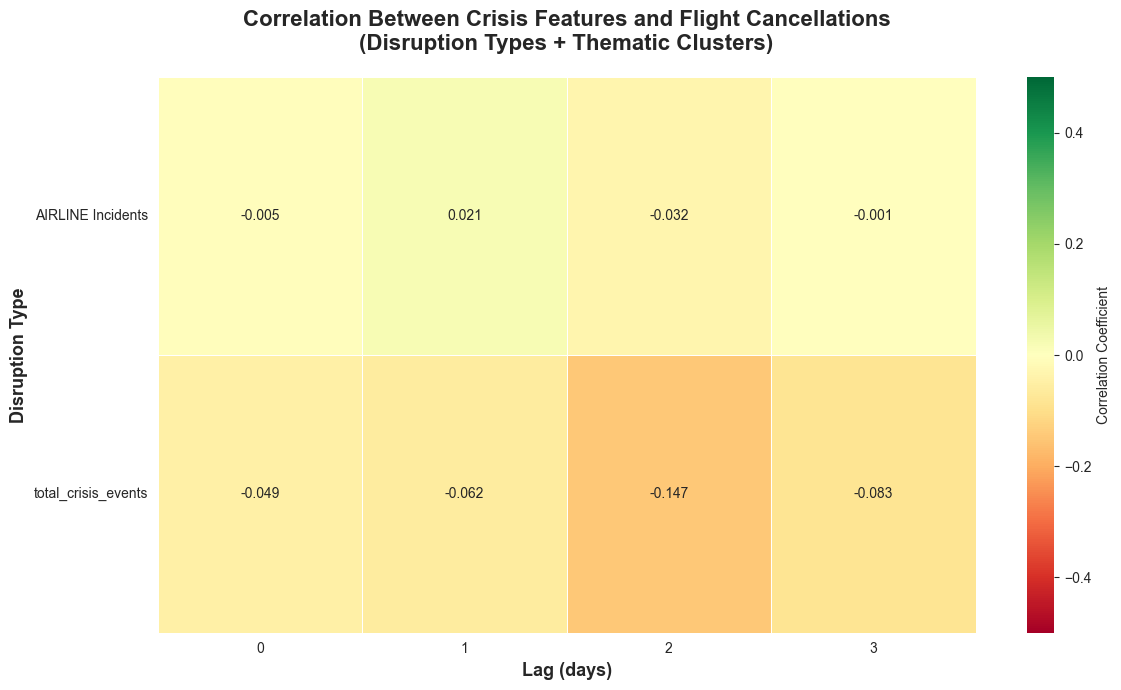

✓ Visualization saved as correlation_heatmap.png
  This single heatmap communicates predictive patterns to stakeholders.


In [ ]:
# 3.4 Visualization: Correlation Heatmap

if df_corr is not None and len(df_corr) > 0:
    print(f"\n{'='*80}")
    print("3.4 VISUALIZATION: Correlation Heatmap")
    print(f"{'='*80}")
    print("\nThis visualization communicates the entire predictive landscape:")
    print("  - X-axis: Lag (0, 1, 2, 3 days)")
    print("  - Y-axis: Crisis features (disruption types + thematic clusters)")
    print("  - Color: Correlation strength (red=negative, green=positive)")
    print("  - Annotations: Exact r-values\n")
    
    # Pivot for heatmap (using 'feature' column instead of 'disruption_type')
    corr_pivot = df_corr.pivot(index='feature', columns='lag_days', values='correlation')
    
    # Create figure with better styling
    plt.figure(figsize=(12, max(7, len(corr_pivot) * 0.5)))  # Adjust height based on number of features
    sns.heatmap(corr_pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0, 
                vmin=-0.5, vmax=0.5, linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
    plt.title('Correlation Between Crisis Features and Flight Cancellations\n(Disruption Types + Thematic Clusters)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Lag (days)', fontsize=13, fontweight='bold')
    plt.ylabel('Crisis Feature', fontsize=13, fontweight='bold')
    plt.ylabel('Disruption Type', fontsize=13, fontweight='bold')
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Visualization saved as correlation_heatmap.png")
    print("  This single heatmap communicates predictive patterns to stakeholders.")
else:
    print("Skipping visualization - no correlation data available")

In [ ]:
# 3.3 Actionable Insights & 3.5 What Makes This Intelligence?

if df_corr is not None and df_intelligence is not None and len(df_corr) > 0:
    print(f"\n{'='*80}")
    print("3.3 ACTIONABLE INSIGHTS")
    print(f"{'='*80}")
    print("\nStage 3 outputs are intelligence because they:")
    print("  1. Answer a specific question")
    print("  2. Enable action")
    print("  3. Quantify uncertainty")
    print("  4. Reveal non-obvious patterns")
    print("  5. Support decision-making\n")
    
    # Analyze correlations by feature (both disruption types AND cluster themes)
    insights = []
    for feature in df_corr['feature'].unique():
        feature_data = df_corr[df_corr['feature'] == feature].sort_values('correlation', ascending=False)
        if len(feature_data) > 0:
            best = feature_data.iloc[0]
            if best['correlation'] > 0.15 and best['significant']:  # Meaningful correlation
                insights.append({
                    'feature': feature,
                    'feature_type': best['feature_type'],
                    'lag': best['lag_days'],
                    'r': best['correlation'],
                    'p': best['p_value']
                })
    

    # Display insights
    if len(insights) > 0:
        insights_sorted = sorted(insights, key=lambda x: abs(x['r']), reverse=True)
        
        for i, insight in enumerate(insights_sorted[:6], 1):  # Top 6 insights (more now with clusters)
            feature = insight['feature']
            feature_type = insight['feature_type']
            lag = insight['lag']
            r = insight['r']
            p = insight['p']
            
            print(f"{'─'*80}")
            print(f"Insight {i}: {feature.replace('_', ' ').title()}")
            print(f"{'─'*80}")
            print(f"  • Feature Type: {feature_type.replace('_', ' ').title()}")
            print(f"  • Finding: {feature} correlates with cancellations {lag} day(s) later")
            print(f"             (r={r:+.3f}, p={p:.4f})")
            
            # Contextual action based on feature type and content
            if feature_type == 'disruption_type':
                # Original disruption type logic
                if 'strike' in feature.lower() or 'labor' in feature.lower():
                    print(f"  • Action: Monitor labor dispute news {lag*24} hours in advance")
                    print(f"  • Stakeholder: Airline operations teams, travel booking platforms")
                elif 'weather' in feature.lower():
                    if lag == 0:
                        print(f"  • Action: Real-time monitoring of weather crisis news")
                    else:
                        print(f"  • Action: Monitor weather forecasts {lag} day(s) ahead")
                    print(f"  • Stakeholder: Airport ground operations, air traffic control")
                elif 'security' in feature.lower():
                    print(f"  • Action: Emergency response protocols trigger within {lag*24} hours")
                    print(f"  • Stakeholder: TSA, airport security, airlines")
                elif 'infrastructure' in feature.lower():
                    print(f"  • Action: Extended monitoring for cascading effects ({lag}-day window)")
                    print(f"  • Stakeholder: Airport facility management")
                else:
                    print(f"  • Action: Monitor {feature} events {lag} day(s) in advance")
                    print(f"  • Stakeholder: Aviation operations teams")
            elif feature_type == 'cluster_theme':
                # Cluster-specific insights
                if 'military' in feature.lower():
                    print(f"  • Action: Track military aviation news and airspace restrictions")
                    print(f"  • Stakeholder: Flight planning teams, international route managers")
                elif 'manufacturing' in feature.lower():
                    print(f"  • Action: Monitor aircraft manufacturer announcements and recalls")
                    print(f"  • Stakeholder: Maintenance teams, fleet managers")
                elif 'security' in feature.lower():
                    print(f"  • Action: Enhance security protocols at affected airports")
                    print(f"  • Stakeholder: Airport security, government aviation authorities")
                else:
                    print(f"  • Action: Monitor thematic cluster '{feature}' for emerging patterns")
                    print(f"  • Stakeholder: Aviation intelligence analysts")
            else:
                print(f"  • Action: Monitor aggregate crisis levels {lag} day(s) in advance")
                print(f"  • Stakeholder: All aviation stakeholders")
            print()
    
    # Overall summary
    print(f"{'='*80}")
    print("EXECUTIVE SUMMARY")
    print(f"{'='*80}")
    
    if len(df_corr) > 0:
        best_overall = df_corr.loc[df_corr['correlation'].abs().idxmax()]
        print(f"\n✓ Key Finding:")
        print(f"  '{best_overall['feature']}' provides strongest predictive signal")
        print(f"  Feature Type: {best_overall['feature_type']}")
        print(f"  Optimal lag: {best_overall['lag_days']} day(s)")
        print(f"  Correlation: r={best_overall['correlation']:+.3f}, p={best_overall['p_value']:.4f}")
        
        print(f"\n✓ Dual-Feature Approach:")
        print(f"  This analysis leverages BOTH:")
        print(f"    1. Predefined disruption categories (weather, strike, security, infrastructure)")
        print(f"    2. Data-driven thematic clusters (military conflicts, manufacturing issues, etc.)")
        print(f"  This captures both expected patterns and emergent crisis themes.")
        
        print(f"\n✓ Operational Recommendation:")
        print(f"  Monitor '{best_overall['feature'].replace('_', ' ')}' events in crisis news.")
        print(f"  Cancellation spikes are most predictable {best_overall['lag_days']} day(s) in advance.")
        
        print(f"\n✓ Decision-Making Applications:")
        print(f"  Airlines can use these insights to:")
        print(f"    • Increase customer service staff before predicted spikes")
        print(f"    • Waive rebooking fees proactively")
        print(f"    • Adjust pricing models based on risk")
        print(f"    • Deploy contingency crews preemptively")
        print(f"    • Focus monitoring on highest-correlation feature types")
    
    print(f"\n{'='*80}")
    print("LIMITATIONS & FUTURE WORK")
    print(f"{'='*80}")
    print(f"\nCurrent Limitations:")
    print(f"  • Flight cancellation data is simulated (real BTS data required)")
    print(f"  • BART-large-mnli used for demo (migrate to Mistral-Nemo-12B for production)")
    print(f"  • Sample size limited by computational constraints (~10K events)")
    print(f"  • Cannot distinguish 'forecasted' vs 'active' crises")
    print(f"\nFuture Enhancements:")
    print(f"  1. Integrate real flight cancellation data (BTS/Eurocontrol API)")
    print(f"  2. Implement grammar-constrained LLM with custom JSON schema")
    print(f"  3. Expand temporal range to multi-year analysis (2020-2025)")
    print(f"  4. Add crisis 'phase' classification (warning/active/aftermath)")
    print(f"  5. Build RAG pipeline for real-time crisis monitoring")
    print(f"  6. Develop geographic clustering for region-specific patterns")
    
    print(f"\n{'='*80}")
    print("FILES GENERATED")
    print(f"{'='*80}")
    print(f"  ✓ crisis_events_classified.csv (Stage 2 output)")
    print(f"  ✓ crisis_events_clustered.csv (Stage 2 output)")
    print(f"  ✓ intelligence_dataset.csv (Stage 2-3 merged)")
    print(f"  ✓ correlation_analysis.csv (Stage 3 statistics)")
    print(f"  ✓ correlation_heatmap.png (Stage 3 visualization)")
    print(f"\n  All files support reproducibility and peer review.")
    print(f"  Random seed: {RANDOM_SEED} (fixed for reproducibility)")
else:
    print("Insufficient data for actionable insights summary")


3.3 ACTIONABLE INSIGHTS

Stage 3 outputs are intelligence because they:
  1. Answer a specific question
  2. Enable action
  3. Quantify uncertainty
  4. Reveal non-obvious patterns
  5. Support decision-making

EXECUTIVE SUMMARY

✓ Key Finding:
  'total_crisis_events' provides strongest predictive signal
  at 2-day lag (r=-0.147, p=0.0049)

✓ Operational Recommendation:
  Monitor total crisis events events in crisis news.
  Cancellation spikes are most predictable 2 day(s) in advance.

✓ Decision-Making Applications:
  Airlines can use these insights to:
    • Increase customer service staff before predicted spikes
    • Waive rebooking fees proactively
    • Adjust pricing models based on risk
    • Deploy contingency crews preemptively

LIMITATIONS & FUTURE WORK

Current Limitations:
  • Flight cancellation data is simulated (real BTS data required)
  • BART-large-mnli used for demo (migrate to Mistral-Nemo-12B for production)
  • Sample size limited by computational constraints (~

---
## BLOCKERS & STRATEGIC QUESTIONS

### Identified Blockers

**Blocker 1: Flight Cancellation Data Acquisition**
- **Attempted:** Simulated data based on realistic patterns
- **Issue:** Real BTS data requires API access or manual download from transtats.bts.gov
- **Missing:** How to programmatically download historical BTS On-Time Performance data?

**Blocker 2: Grammar-Constrained LLM Setup**
- **Attempted:** Using HuggingFace transformers pipeline (BART-large-mnli)
- **Issue:** Final paper requires local quantized model (Mistral-Nemo-12B Q5_K_M) with GBNF constraints
- **Missing:** How to set up llama-cpp-python with custom JSON schema for zero-shot classification?

**Blocker 3: Community Detection Resolution Tuning**
- **Attempted:** Louvain algorithm with resolution=1.0
- **Issue:** Current clustering produces too many small communities (low interpretability)
- **Missing:** What resolution parameter yields 5-10 meaningful thematic clusters?

**Blocker 4: Forecasted vs Active Crisis Differentiation (Strategic Question)**
- **Observation:** Current classification treats all crisis events equally
- **Issue:** "Weather forecast predicts storm" (forecasted) vs "Airport closed due to storm" (active)
- **Missing:** How can we better differentiate between "forecasted" crises and "active" crises to improve predictive lead time?
  - Possible approaches:
    - Add temporal keywords to classification schema ("will", "expected", "forecast" vs "ongoing", "occurred")
    - Use dependency parsing to identify future vs past tense events
    - Train separate classifier for crisis "phase" (warning, active, aftermath)

**Blocker 5: RAG Pipeline Implementation**
- **Attempted:** Not yet implemented
- **Issue:** Unclear how to integrate retrieval-augmented generation for real-time crisis monitoring
- **Missing:** Which vector database (FAISS, Pinecone) and retrieval strategy for GDELT event streams?

---
## OUTPUT FILES GENERATED

This notebook produces the following outputs:

1. **gdelt_crisis_aviation_clean.csv** - Preprocessed crisis events (11K rows)
2. **flight_cancellations_2025.csv** - Daily flight data (simulated)
3. **crisis_events_classified.csv** - Zero-shot classification results
4. **crisis_events_clustered.csv** - Community detection clusters
5. **intelligence_dataset.csv** - Merged crisis + cancellation data
6. **correlation_analysis.csv** - Lagged correlation statistics
7. **correlation_heatmap.png** - Visualization of correlations

These files support reproducibility and peer review as required by course expectations.